# HPO del GA — Semana 8

Comparamos búsqueda aleatoria vs. bayesiana (Optuna/TPE) para calibrar los hiperparámetros
del GA sobre la viga de 3 tramos. Los mejores hallazgos se validan luego en las 3 vigas.

| Hiperparámetro | Rango |
|---|---|
| `pop_size` | 50 – 150 (paso 10) |
| `n_gen` | 30 – 100 (paso 10) |
| `tournament_k` | 2 – 8 |

In [3]:
%matplotlib inline
import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

ROOT = Path(os.getcwd()).parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from beam_n import BeamGANSpans, ensure_joints

DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'notebooks' / 'output'
OUT_DIR.mkdir(exist_ok=True)

N_TRIALS  = 25
SEED_OPT  = 0     # semilla de los samplers
SEED_GA   = 42    # semilla fija del GA en cada trial
SEEDS_VAL = [42, 123, 7]

print('Imports OK — ROOT:', ROOT)

Imports OK — ROOT: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl


In [4]:
beams = []
for p in sorted(DATA_DIR.glob('beam_*.json')):
    b = json.loads(p.read_text(encoding='utf-8'))
    ensure_joints(b)
    beams.append(b)
    print(f"{p.name}  n_spans={b['n_spans']}  id={b['id']}")

viga_3t = next(b for b in beams if b['n_spans'] == 3)
print(f'\nObjetivo HPO: {viga_3t["id"]}  ({viga_3t["n_spans"]} tramos)')

beam_viga_1_tramos.json  n_spans=1  id=28
beam_viga_2_tramos.json  n_spans=2  id=110+114
beam_viga_3_tramos.json  n_spans=3  id=18+17+16

Objetivo HPO: 18+17+16  (3 tramos)


## Función objetivo

Cada trial lanza un *scout* con un tercio del presupuesto de generaciones.
El `MedianPruner` de Optuna descarta el trial si ese fitness intermedio
supera la mediana de los trials previos — el GA también tiene su propio
early stopping interno por paciencia.

In [5]:
def objective(trial, beam):
    pop  = trial.suggest_int('pop_size',      50, 150, step=10)
    ngen = trial.suggest_int('n_gen',         30, 100, step=10)
    tk   = trial.suggest_int('tournament_k',   2,   8)

    n_scout = max(10, ngen // 3)
    r_scout = BeamGANSpans(beam, pop_size=pop, n_gen=n_scout,
                           tournament_k=tk, seed=SEED_GA).run()
    trial.report(r_scout['top3'][0]['fitness'], step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    ga = BeamGANSpans(beam, pop_size=pop, n_gen=ngen, tournament_k=tk, seed=SEED_GA)
    r  = ga.run()
    top = r['top3'][0]

    trial.set_user_attr('feasible',   top['feasible'])
    trial.set_user_attr('weight_kg',  round(top['total_weight_kg'], 2))
    trial.set_user_attr('zones_ok',   top['zones_ok'])
    trial.set_user_attr('n_zones',    ga.n_zones)
    trial.set_user_attr('early_stop', r['early_stop'])
    trial.set_user_attr('gens_run',   r['generations_run'])
    return top['fitness']

## Búsqueda aleatoria

In [6]:
storage = f"sqlite:///{OUT_DIR}/hpo_studies.db"
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)

study_rand = optuna.create_study(
    study_name='random_search',
    direction='minimize',
    sampler=optuna.samplers.RandomSampler(seed=SEED_OPT),
    pruner=pruner,
    storage=storage,
    load_if_exists=True,
)

t0 = time.time()
study_rand.optimize(lambda t: objective(t, viga_3t), n_trials=N_TRIALS, show_progress_bar=True)

n_pruned = sum(1 for t in study_rand.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f'\nRandom  {time.time()-t0:.0f}s  '
      f'completados={len(study_rand.trials)-n_pruned}  podados={n_pruned}')
print(f'Mejor: {study_rand.best_value:.4f}  params={study_rand.best_params}')

  0%|          | 0/25 [00:00<?, ?it/s]

  Gen   1/26 | best=1964.68 | mean=71707.18 | HoF=239.61kg (18/18 OK) | sin mejora= 0 | 1.1s
  Gen   2/26 | best=385.32 | mean=41296.85 | HoF=242.51kg (18/18 OK) | sin mejora= 0 | 2.4s
  Gen   3/26 | best=271.68 | mean=41951.04 | HoF=241.51kg (18/18 OK) | sin mejora= 0 | 3.9s
  Gen   4/26 | best=271.68 | mean=41918.08 | HoF=241.51kg (18/18 OK) | sin mejora= 1 | 5.3s
  Gen   5/26 | best=271.68 | mean=44180.85 | HoF=241.51kg (18/18 OK) | sin mejora= 2 | 6.7s
  Gen   6/26 | best=271.68 | mean=44855.46 | HoF=241.51kg (18/18 OK) | sin mejora= 3 | 8.1s
  Gen   7/26 | best=271.68 | mean=47942.49 | HoF=241.51kg (18/18 OK) | sin mejora= 4 | 9.7s
  Gen   8/26 | best=271.68 | mean=48476.44 | HoF=241.51kg (18/18 OK) | sin mejora= 5 | 11.2s
  Gen   9/26 | best=271.68 | mean=41223.44 | HoF=241.51kg (18/18 OK) | sin mejora= 6 | 12.7s
  Gen  10/26 | best=271.68 | mean=44635.74 | HoF=241.51kg (18/18 OK) | sin mejora= 7 | 14.1s
  Gen  11/26 | best=271.68 | mean=38848.96 | HoF=241.51kg (18/18 OK) | sin m

## Búsqueda bayesiana (TPE)

In [7]:
study_tpe = optuna.create_study(
    study_name='tpe_search',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED_OPT),
    pruner=pruner,
    storage=storage,
    load_if_exists=True,
)

t0 = time.time()
study_tpe.optimize(lambda t: objective(t, viga_3t), n_trials=N_TRIALS, show_progress_bar=True)

n_pruned = sum(1 for t in study_tpe.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f'\nTPE  {time.time()-t0:.0f}s  '
      f'completados={len(study_tpe.trials)-n_pruned}  podados={n_pruned}')
print(f'Mejor: {study_tpe.best_value:.4f}  params={study_tpe.best_params}')

  0%|          | 0/25 [00:00<?, ?it/s]

  Gen   1/26 | best=1964.68 | mean=71707.18 | HoF=239.61kg (18/18 OK) | sin mejora= 0 | 0.9s
  Gen   2/26 | best=385.32 | mean=41296.85 | HoF=242.51kg (18/18 OK) | sin mejora= 0 | 2.2s
  Gen   3/26 | best=271.68 | mean=41951.04 | HoF=241.51kg (18/18 OK) | sin mejora= 0 | 3.4s
  Gen   4/26 | best=271.68 | mean=41918.08 | HoF=241.51kg (18/18 OK) | sin mejora= 1 | 4.7s
  Gen   5/26 | best=271.68 | mean=44180.85 | HoF=241.51kg (18/18 OK) | sin mejora= 2 | 5.9s
  Gen   6/26 | best=271.68 | mean=44855.46 | HoF=241.51kg (18/18 OK) | sin mejora= 3 | 7.3s
  Gen   7/26 | best=271.68 | mean=47942.49 | HoF=241.51kg (18/18 OK) | sin mejora= 4 | 8.7s
  Gen   8/26 | best=271.68 | mean=48476.44 | HoF=241.51kg (18/18 OK) | sin mejora= 5 | 10.1s
  Gen   9/26 | best=271.68 | mean=41223.44 | HoF=241.51kg (18/18 OK) | sin mejora= 6 | 11.3s
  Gen  10/26 | best=271.68 | mean=44635.74 | HoF=241.51kg (18/18 OK) | sin mejora= 7 | 12.6s
  Gen  11/26 | best=271.68 | mean=38848.96 | HoF=241.51kg (18/18 OK) | sin m

## Top-k y gráfico de evolución

In [8]:
def to_df(study, label):
    rows = []
    for t in study.trials:
        if t.state != optuna.trial.TrialState.COMPLETE:
            continue
        rows.append({
            'sampler':      label,
            'trial':        t.number,
            'fitness':      round(t.value, 4),
            'weight_kg':    t.user_attrs.get('weight_kg'),
            'feasible':     t.user_attrs.get('feasible'),
            'zones_ok':     t.user_attrs.get('zones_ok'),
            'n_zones':      t.user_attrs.get('n_zones'),
            'pop_size':     t.params['pop_size'],
            'n_gen':        t.params['n_gen'],
            'tournament_k': t.params['tournament_k'],
            'early_stop':   t.user_attrs.get('early_stop'),
            'gens_run':     t.user_attrs.get('gens_run'),
        })
    return pd.DataFrame(rows).sort_values('fitness').reset_index(drop=True)

df_rand = to_df(study_rand, 'Random')
df_tpe  = to_df(study_tpe,  'TPE')
df_all  = pd.concat([df_rand, df_tpe]).sort_values('fitness').reset_index(drop=True)

print('=== Top-10 (ambos samplers) ===')
print(df_all.head(10).to_string(index=False))

df_all.to_csv(OUT_DIR / 'hpo_top_k.csv', index=False)
print(f'\nGuardado: hpo_top_k.csv')

=== Top-10 (ambos samplers) ===
sampler  trial  fitness  weight_kg  feasible  zones_ok  n_zones  pop_size  n_gen  tournament_k  early_stop  gens_run
 Random      0  253.714     253.71      True        18       18       110     80             6       False        80
 Random      7  253.714     253.71      True        18       18       130     60             7       False        60
 Random      6  253.714     253.71      True        18       18       130     90             8        True        69
 Random      4  253.714     253.71      True        18       18       110    100             2        True        94
 Random     12  253.714     253.71      True        18       18       110     70             8        True        62
 Random     10  253.714     253.71      True        18       18        70     90             5        True        65
 Random      9  253.714     253.71      True        18       18       150     70             4       False        70
 Random      8  253.714     253.

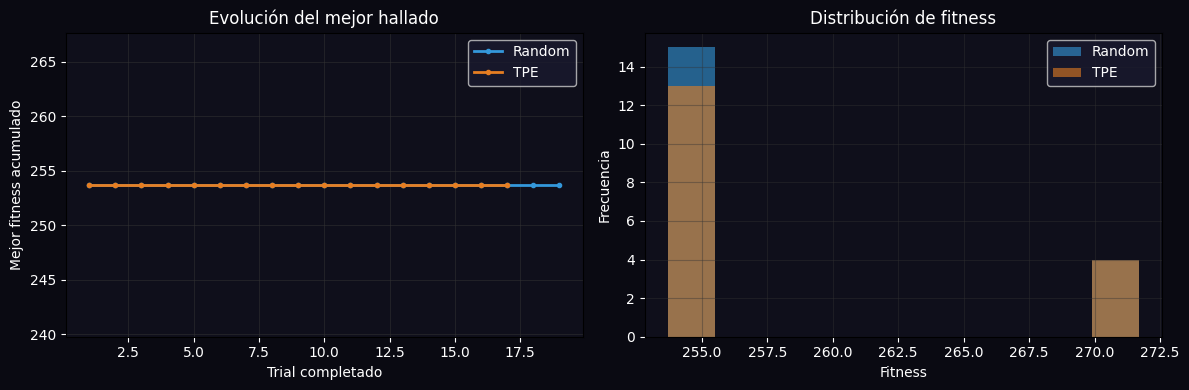

Guardado: hpo_evolucion.png


In [9]:
def mejor_acumulado(study):
    completos = sorted(
        [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
        key=lambda t: t.number,
    )
    best, serie = float('inf'), []
    for t in completos:
        best = min(best, t.value)
        serie.append(best)
    return serie

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0a0a12')

# evolución del mejor
ax = axes[0]
ax.set_facecolor('#0f0f1b')
for study, label, color in [(study_rand, 'Random', '#3498db'), (study_tpe, 'TPE', '#e67e22')]:
    serie = mejor_acumulado(study)
    ax.plot(range(1, len(serie)+1), serie, color=color, lw=2, marker='o', ms=3, label=label)
ax.set_xlabel('Trial completado', color='white')
ax.set_ylabel('Mejor fitness acumulado', color='white')
ax.set_title('Evolución del mejor hallado', color='white')
ax.tick_params(colors='white')
ax.grid(True, color='#333', alpha=0.5)
ax.legend(facecolor='#1a1a2e', labelcolor='white')

# distribución de fitness por sampler
ax2 = axes[1]
ax2.set_facecolor('#0f0f1b')
data_r = df_rand['fitness'].dropna().values
data_t = df_tpe['fitness'].dropna().values
ax2.hist(data_r, bins=10, color='#3498db', alpha=0.6, label='Random')
ax2.hist(data_t, bins=10, color='#e67e22', alpha=0.6, label='TPE')
ax2.set_xlabel('Fitness', color='white')
ax2.set_ylabel('Frecuencia', color='white')
ax2.set_title('Distribución de fitness', color='white')
ax2.tick_params(colors='white')
ax2.grid(True, color='#333', alpha=0.4)
ax2.legend(facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
path = OUT_DIR / 'hpo_evolucion.png'
plt.savefig(path, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Guardado: hpo_evolucion.png')

## Validación: top-3 en las 3 vigas

Las 3 mejores configs (priorizando factibilidad) se corren en cada viga con 3 seeds
para evaluar si los hiperparámetros hallados en 3 tramos generalizan.

In [10]:
factibles = df_all[df_all['feasible'] == True]
top3 = (factibles if len(factibles) >= 3 else df_all).head(3).reset_index(drop=True)

print('Configs seleccionadas para validación:')
print(top3[['sampler', 'fitness', 'weight_kg', 'pop_size', 'n_gen', 'tournament_k']].to_string(index=False))

Configs seleccionadas para validación:
sampler  fitness  weight_kg  pop_size  n_gen  tournament_k
 Random  253.714     253.71       110     80             6
 Random  253.714     253.71       130     60             7
 Random  253.714     253.71       130     90             8


In [ ]:
val_records = []

for rank, cfg in top3.iterrows():
    pop, ngen, tk = int(cfg['pop_size']), int(cfg['n_gen']), int(cfg['tournament_k'])
    cfg_label = f"pop={pop} gen={ngen} tk={tk}"
    for beam in beams:
        for seed in SEEDS_VAL:
            ga  = BeamGANSpans(beam, pop_size=pop, n_gen=ngen, tournament_k=tk, seed=seed)
            r   = ga.run()
            top = r['top3'][0]
            val_records.append({
                'rank':      rank + 1,
                'config':    cfg_label,
                'sampler':   cfg['sampler'],
                'beam_id':   beam['id'],
                'n_spans':   beam['n_spans'],
                'seed':      seed,
                'weight_kg': round(top['total_weight_kg'], 2),
                'feasible':  top['feasible'],
                'zones_ok':  top['zones_ok'],
                'n_zones':   ga.n_zones,
                'fitness':   round(top['fitness'], 4),
            })
            print(f"  [{cfg_label}]  {beam['id']}  seed={seed}  "
                  f"W={top['total_weight_kg']:.1f}kg  "
                  f"feas={top['feasible']}  "
                  f"zones={top['zones_ok']}/{ga.n_zones}")

df_val = pd.DataFrame(val_records)
df_val.to_csv(OUT_DIR / 'hpo_validacion.csv', index=False)
print('\nGuardado: hpo_validacion.csv')

  Gen   1/80 | best=37.43 | mean=14280.76 | HoF=37.43kg (6/6 OK) | sin mejora= 0 | 0.3s
  Gen   4/80 | best=37.43 | mean=30092.75 | HoF=37.43kg (6/6 OK) | sin mejora= 3 | 1.6s
  Gen   8/80 | best=37.43 | mean=38252.98 | HoF=37.43kg (6/6 OK) | sin mejora= 7 | 3.3s
  Gen  12/80 | best=37.43 | mean=25209.46 | HoF=37.43kg (6/6 OK) | sin mejora=11 | 5.0s
  Gen  16/80 | best=37.43 | mean=25808.63 | HoF=37.43kg (6/6 OK) | sin mejora=15 | 6.7s
  Gen  20/80 | best=37.43 | mean=30357.04 | HoF=37.43kg (6/6 OK) | sin mejora=19 | 8.4s
  Gen  24/80 | best=37.43 | mean=31069.89 | HoF=37.43kg (6/6 OK) | sin mejora=23 | 10.1s
  [Reinicio #1] Gen 26 -- reemplazados 55 (11.0s)
  Gen  28/80 | best=37.43 | mean=32424.08 | HoF=37.43kg (6/6 OK) | sin mejora=27 | 11.9s
  Gen  32/80 | best=37.43 | mean=31024.55 | HoF=37.43kg (6/6 OK) | sin mejora=31 | 13.5s
  Gen  36/80 | best=37.43 | mean=26459.04 | HoF=37.43kg (6/6 OK) | sin mejora=35 | 15.1s
  Gen  40/80 | best=37.43 | mean=37466.13 | HoF=37.43kg (6/6 OK) |

In [ ]:
resumen = (
    df_val.groupby(['rank', 'config', 'sampler', 'n_spans'])
    .agg(
        W_media=('weight_kg', 'mean'),
        W_std  =('weight_kg', 'std'),
        feas_pct=('feasible', lambda x: x.mean() * 100),
    )
    .reset_index()
    .round(2)
    .sort_values(['n_spans', 'feas_pct', 'W_media'], ascending=[True, False, True])
)

print('=== Resumen validación ===')
print(resumen.to_string(index=False))

# Config ganadora: mejor feasibility y menor peso en 3 tramos
cands = resumen[resumen['n_spans'] == 3].sort_values(
    ['feas_pct', 'W_media'], ascending=[False, True]
)
ganador = cands.iloc[0]
print(f'\n=== Config ganadora ===')
print(f'  {ganador["config"]}  (sampler: {ganador["sampler"]})')
print(f'  W̄={ganador["W_media"]:.2f} ± {ganador["W_std"]:.2f} kg  '
      f'factibilidad={ganador["feas_pct"]:.0f}%')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.patch.set_facecolor('#0a0a12')
colores = ['#3498db', '#e67e22', '#2ecc71']

for col, (n_sp, label) in enumerate([(1, '1 tramo'), (2, '2 tramos'), (3, '3 tramos')]):
    ax = axes[col]
    ax.set_facecolor('#0f0f1b')
    sub = resumen[resumen['n_spans'] == n_sp].reset_index(drop=True)
    x   = np.arange(len(sub))

    bars = ax.bar(x, sub['W_media'], yerr=sub['W_std'],
                  color=[colores[i] for i in range(len(sub))],
                  error_kw=dict(ecolor='white', capsize=5, lw=1.2),
                  alpha=0.85)
    for bar, feas in zip(bars, sub['feas_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{feas:.0f}%', ha='center', va='bottom', color='white', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f'cfg{i+1}' for i in range(len(sub))], color='white', fontsize=8)
    ax.set_title(label, color='white')
    ax.set_ylabel('Peso acero (kg)' if col == 0 else '', color='white')
    ax.tick_params(colors='white')
    ax.grid(True, axis='y', color='#333', alpha=0.4)

fig.suptitle('Validación top-3 configs en las 3 vigas  (% = factibilidad)', color='white')
plt.tight_layout()
path = OUT_DIR / 'hpo_validacion.png'
plt.savefig(path, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Guardado: hpo_validacion.png')

## Resumen

| | |
|---|---|
| **Espacio** | `pop_size` ∈ {50…150}, `n_gen` ∈ {30…100}, `tournament_k` ∈ {2…8} — 3 hiperparámetros, ~180 configs posibles |
| **Presupuesto** | 25 trials × 2 samplers = 50 evaluaciones (+ podados por MedianPruner) |
| **Early stopping** | el GA corta si no mejora por N generaciones; Optuna poda trials con fitness scout > mediana |
| **Config ganadora** | ver celda anterior — validada en las 3 vigas × 3 seeds |
| **Artefactos** | `hpo_studies.db`, `hpo_top_k.csv`, `hpo_validacion.csv`, `hpo_evolucion.png`, `hpo_validacion.png` |